In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from encoder_decoder import*
import matplotlib.pyplot as plt

# Check vocab and define encoding/decoding functions (from int to char and viceversa)

In [2]:
# first import the little dictionary frol it_es_cognates.txt

italian_words = []
spanish_words = []

with open("it_es_cognates.txt", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        it, es = line.split(";") # words separated by ;
        italian_words.append(it.lower())
        spanish_words.append(es.lower())

# check the number of words in the list of cognates
print(len(italian_words), "pairs")
print(italian_words[:5], spanish_words[:5])

# find all characters appearing in the list of cognates
all_chars = set()
for word in spanish_words + italian_words:
    all_chars.update(word)
all_chars = sorted(all_chars)

# add the special caracters: pad, start of string, end of string, unknown
specials = ['<pad>', '<sos>', '<eos>', '<unk>']
vocab = specials + all_chars

# build the dictionaries, just use the enumeration of vocab to assign an integer to every character
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

# check the characters in the vocabulary, and its length
print("vocab: ", vocab)
print("vocab length:", len(vocab))

# test word size in the vocabulary (need to know the dimension of the words I am going to have in the model - by padding)
# I will add 2 or 3 just to be on the safe side for future additions to the dictionary, getting, say, to 20
print("Max length of spanish words: ", max(len(w) for w in spanish_words))
print("Max length of italian words: ", max(len(w) for w in italian_words))

def encode_source(word, max_len = 20):
    # input: no sos/eos needed
    ids = [char_to_idx.get(c, char_to_idx['<unk>']) for c in word][:max_len] # use the char to int dictionary
    ids += [char_to_idx['<pad>']] * (max_len - len(ids)) # fill with '<pad>' until the prescribed length max_len
    return torch.tensor(ids)

def encode_target(word, max_len = 20):
    # output: needs sos/eos since decoder generates it step by step, they will replace two <pad> 
    ids = [char_to_idx['<sos>']] + [char_to_idx.get(c, char_to_idx['<unk>']) for c in word][:max_len-2] + [char_to_idx['<eos>']]
    ids += [char_to_idx['<pad>']] * (max_len - len(ids))
    return torch.tensor(ids) 

def decode_source(ids):
    
    ids_numpy = ids.numpy()
    chars = []
    for i in ids_numpy:
        ch = idx_to_char[i] # use the integer to char dictionary
        if ch == '<pad>':
            break  # padding marks the end of real content
        chars.append(ch)
    return ''.join(chars)

# test
print(encode_source('castoro'))
print(decode_source(encode_source('castoro'))) 
print(decode_source(encode_source('è'))) # check unknown characters


# now test the embedding
vocab_size = len(char_to_idx)
d_model = 32 # needs to be large enough but does not have to be larger than number of characters - in fact for LLMs it is smaller than the number of tokens
embed = nn.Embedding(vocab_size, d_model, padding_idx=char_to_idx['<pad>'])

print(embed(encode_source('castoro')))

908 pairs
['acqua', 'aglio', 'aiutare', 'aiutata', 'aiutate'] ['agua', 'ajo', 'ayudar', 'ayudada', 'ayudadas']
vocab:  ['<pad>', '<sos>', '<eos>', '<unk>', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y', 'z', 'à', 'á', 'é', 'í', 'ñ', 'ó', 'ù', 'ú']
vocab length: 36
Max length of spanish words:  15
Max length of italian words:  13
tensor([ 6,  4, 21, 22, 17, 20, 17,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0])
castoro
<unk>
tensor([[-1.6267e-01, -8.9861e-01,  6.4217e-01, -1.3281e+00,  1.0387e+00,
         -7.4494e-01, -1.2216e-01, -1.1409e+00,  2.0156e+00, -1.6644e+00,
         -7.8378e-01,  3.3492e-01, -3.3145e-01,  2.7267e+00, -9.0700e-01,
          4.6631e-01,  2.1329e-01,  7.6274e-01,  1.3950e+00,  2.0557e-01,
          7.6700e-01,  1.3418e+00,  8.8172e-01, -3.8580e-01,  1.1501e+00,
         -3.6139e-01, -8.5276e-01,  5.8318e-01, -1.7500e+00, -1.2375e+00,
          2.0201e+00, -8.0646e-01],
        [-

# Various tests done while coding the class

In [3]:
# test if Encoder runs correctly

enco = Encoder(2, d_model = d_model, d_hidden = 4*d_model, dk = 8, dv = 8, h = 4)
pos_enco = PositionalEncodingModule(d_model=d_model)

encoded_word = pos_enco(enco(embed(encode_source('castoro')).unsqueeze(0)))
# print(encoded_word)

# ok

# test if Transformer runs correctly 

trafo = Transformer(n_layers = 3, d_model = d_model, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8)

print(trafo(encode_source("castoro").unsqueeze(0), encode_source("diga").unsqueeze(0)))
print(trafo.generate_sequence(encode_source("castoro").unsqueeze(0)))

tensor([[[ 6.0284e-03,  3.0408e-01,  5.4221e-01, -9.9917e-02, -5.3805e-01,
          -6.8512e-01,  2.0110e-01,  2.1622e-01, -8.7835e-01, -3.2306e-01,
          -1.6916e-04, -9.5237e-01, -4.4603e-01,  1.2598e-01, -1.6661e-02,
           3.4008e-01, -6.3204e-01, -8.9987e-01,  1.8511e+00, -4.2346e-01,
          -1.5996e+00, -8.4287e-01, -3.7399e-03, -2.0117e-01,  3.4630e-01,
           1.5870e+00, -6.7240e-02,  1.3638e-01,  2.9234e-01, -3.6679e-01,
           7.1036e-01,  1.1893e+00,  2.5764e-03, -1.1733e+00,  1.9422e-01,
           3.5539e-01],
         [-5.9351e-01,  6.3963e-01, -7.6761e-02,  1.4772e-01,  5.7021e-01,
           2.0680e-01, -6.9278e-01,  8.5336e-01, -1.4426e+00, -1.6152e-01,
           1.1357e-01, -9.5612e-01,  1.9778e-01, -1.3988e-01, -4.8425e-01,
           1.5692e-01, -4.4318e-01, -4.4663e-01,  1.2500e+00, -3.3533e-01,
           2.1322e-01, -2.9397e-01, -6.5028e-02, -1.3754e-01, -2.1789e-02,
           3.7750e-01, -3.4709e-01,  1.5029e-01,  4.3808e-02, -9.9476e-01,
 

In [4]:
def count_parameters_by_module(model: nn.Module, trainable_only: bool = True) -> dict:
    """counts the number of parameters, in total and for every submodule"""
    counts = {}
    for name, module in model.named_children():
        if trainable_only:
            n = sum(p.numel() for p in module.parameters() if p.requires_grad)
        else:
            n = sum(p.numel() for p in module.parameters())
        counts[name] = n
    counts["TOTAL"] = sum(counts.values())
    return counts

count_parameters_by_module(trafo)

{'embed': 1152,
 'pos_encoding': 0,
 'encoder': 38112,
 'decoder': 50976,
 'exit_linear_projection': 1188,
 'criterion': 0,
 'TOTAL': 91428}

# Fit the model

In [ ]:
trafo = Transformer(n_layers = 3, d_model = d_model, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8)
trafo.fit_from_txt("it_es_cognates.txt", n_epochs=750)

Epoch  0 / 1000  loss =  tensor(3.9771, device='mps:0', grad_fn=<NllLoss2DBackward0>)
Epoch  50 / 1000  loss =  tensor(0.6201, device='mps:0', grad_fn=<NllLoss2DBackward0>)
Epoch  100 / 1000  loss =  tensor(0.9641, device='mps:0', grad_fn=<NllLoss2DBackward0>)
Epoch  150 / 1000  loss =  tensor(0.0187, device='mps:0', grad_fn=<NllLoss2DBackward0>)
Epoch  200 / 1000  loss =  tensor(0.0065, device='mps:0', grad_fn=<NllLoss2DBackward0>)
Epoch  250 / 1000  loss =  tensor(0.0049, device='mps:0', grad_fn=<NllLoss2DBackward0>)
Epoch  300 / 1000  loss =  tensor(0.0038, device='mps:0', grad_fn=<NllLoss2DBackward0>)
Epoch  350 / 1000  loss =  tensor(0.0034, device='mps:0', grad_fn=<NllLoss2DBackward0>)
Epoch  400 / 1000  loss =  tensor(0.0030, device='mps:0', grad_fn=<NllLoss2DBackward0>)
Epoch  450 / 1000  loss =  tensor(0.0029, device='mps:0', grad_fn=<NllLoss2DBackward0>)
Epoch  500 / 1000  loss =  tensor(0.0027, device='mps:0', grad_fn=<NllLoss2DBackward0>)
Epoch  550 / 1000  loss =  tensor(0

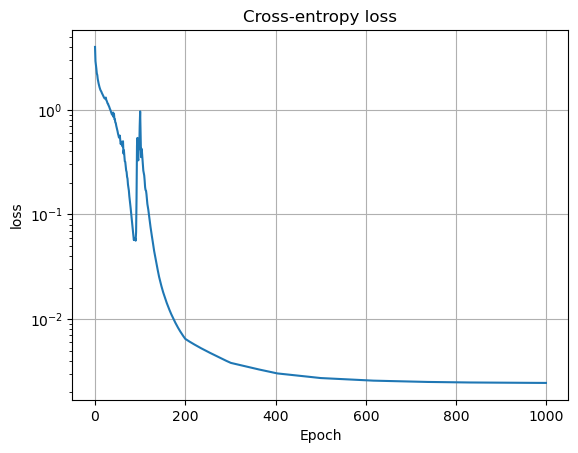

TypeError: unhashable type: 'numpy.ndarray'

In [16]:
plt.figure()
plt.title('Cross-entropy loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.grid()
plt.semilogy(trafo.epochs, trafo.losses)
plt.show()


print(decode_source(trafo.generate_sequence(encode_source("castoro").unsqueeze(0)).cpu()))


